In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image

In [6]:
tf.random.set_seed(42)
print('Tensorflow version', tf.__version__)

Tensorflow version 2.19.0


In [7]:
# Download DataSet from Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d omkargurav/face-mask-dataset
!unzip -qq face-mask-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 95% 155M/163M [00:00<00:00, 1.62GB/s]
100% 163M/163M [00:00<00:00, 1.59GB/s]


In [8]:
base_dir = 'data'
print('Dataset Folder', os.listdir(base_dir))

Dataset Folder ['with_mask', 'without_mask']


In [9]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training',
    seed=42
)

Found 6043 images belonging to 2 classes.


In [10]:
test_data = datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    seed=42
)

Found 1510 images belonging to 2 classes.


In [11]:
# Crete the CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, 3, activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,281 (9.90 MB)

 Trainable params: 2,595,281 (9.90 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(train_data, epochs=5, validation_data=test_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
 48/189 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.6851 - loss: 0.6581

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 38s 140ms/step - accuracy: 0.7818 - loss: 0.4869 - val_accuracy: 0.9159 - val_loss: 0.2337
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.8861 - loss: 0.2771 - val_accuracy: 0.9132 - val_loss: 0.2265
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.9005 - loss: 0.2302 - val_accuracy: 0.9477 - val_loss: 0.1815
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.9151 - loss: 0.2137 - val_accuracy: 0.9079 - val_loss: 0.2375
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.9250 - loss: 0.1902 - val_accuracy: 0.9252 - val_loss: 0.1894


In [15]:
# Evaluate
loss, accuracy = model.evaluate(test_data)
print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9294 - loss: 0.1749
Loss: 0.18940965831279755
Accuracy: 0.9251655340194702


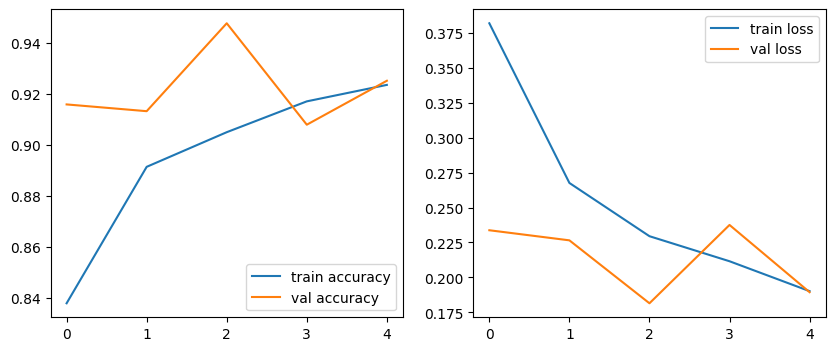

In [16]:
# Plot Accuracy and Loss
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step


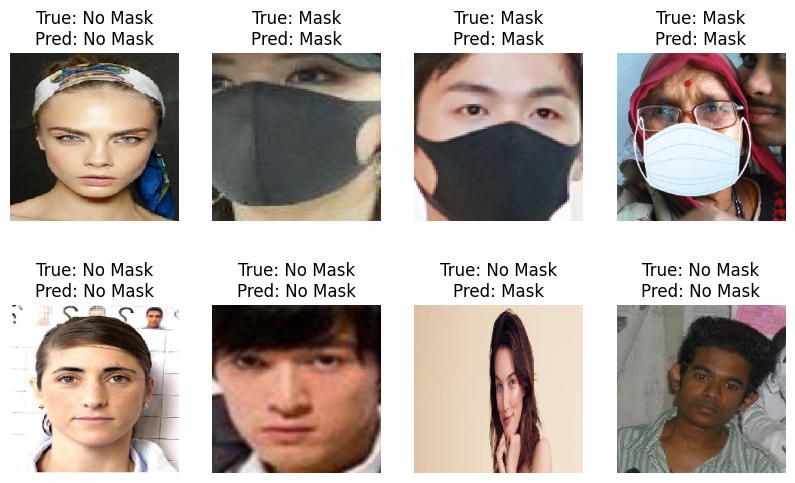

In [17]:
images, label = next(test_data)
predictions = model.predict(images)
plt.figure(figsize=(10,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    true_label = 'Mask' if label[i] == 0 else 'No Mask'
    pred_label = 'Mask' if predictions[i] < 0.5 else 'No Mask'
    plt.title(f'True: {true_label}\nPred: {pred_label}')
    plt.axis('off')
plt.show()

Saving no-mask.jpg to no-mask.jpg
File Uploaded:  no-mask.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 746ms/step
Prediction: No Mask
Confident:  93.484245 %


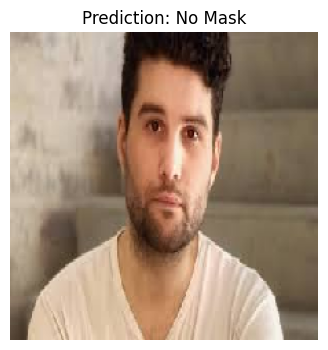

In [18]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
    path = fn
    print('File Uploaded: ', path)
    img = image.load_img(path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)/255.0

    pred = model.predict(img_array)[0][0]
    label = 'Mask' if pred < 0.5 else 'No Mask'
    print(f'Prediction: {label}')
    print('Confident: ', 100*(1-pred) if pred < 0.5 else 100*pred, '%')

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f'Prediction: {label}')
    plt.axis('off')
    plt.show()

In [20]:
model.save('FaceMaskCNNmodel.keras')
print(f"Model saved!")

Model saved!
